<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None
         survived      pclass         age       sibsp       parch        fare
count  891

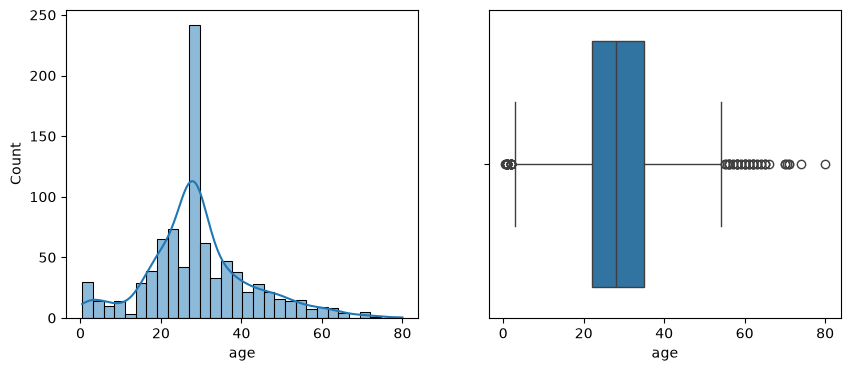

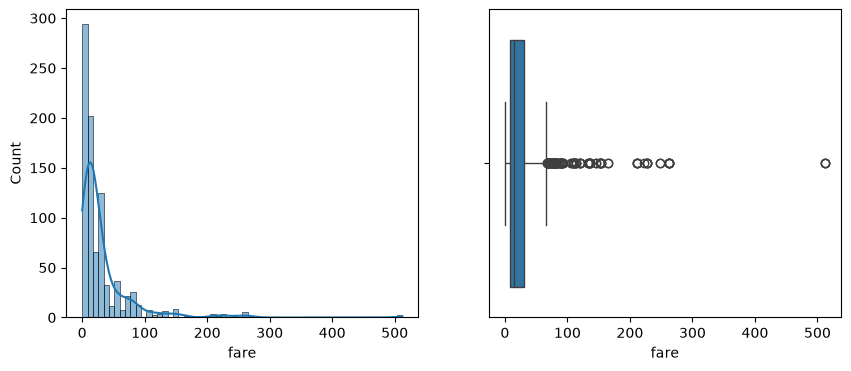

66
116
32.204207968574636 14.4542 8.05
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64
sex     pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


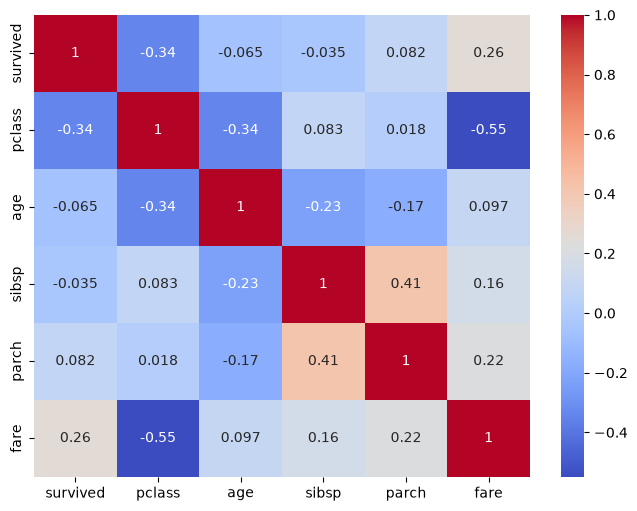

age_scaled     2.272780e-16
fare_scaled    3.987333e-18
dtype: float64
age_scaled     1.000562
fare_scaled    1.000562
dtype: float64


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = sns.load_dataset('titanic')
df.to_csv("titanic.csv", index=False)

print(df.info())
print(df.describe())
print(df.shape)

missing_percentages = (df.isnull().sum() / len(df)) * 100
print(missing_percentages[missing_percentages > 0])

df['age'] = df['age'].fillna(df['age'].median())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.drop(columns=['deck'], inplace=True)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['age'])
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['fare'], kde=True)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['fare'])
plt.show()

q1_age, q3_age = df['age'].quantile(0.25), df['age'].quantile(0.75)
iqr_age = q3_age - q1_age
age_outliers = df[(df['age'] < q1_age - 1.5 * iqr_age) | (df['age'] > q3_age + 1.5 * iqr_age)]
print(len(age_outliers))

q1_fare, q3_fare = df['fare'].quantile(0.25), df['fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
fare_outliers = df[(df['fare'] < q1_fare - 1.5 * iqr_fare) | (df['fare'] > q3_fare + 1.5 * iqr_fare)]
print(len(fare_outliers))

fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]
print(fare_mean, fare_median, fare_mode)

print(df.groupby('sex')['survived'].mean())
print(df.groupby('pclass')['survived'].mean())
print(df.groupby(['sex', 'pclass'])['survived'].mean())

num_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])
df['fare_scaled'] = scaler.fit_transform(df[['fare']])
print(df[['age_scaled', 'fare_scaled']].mean())
print(df[['age_scaled', 'fare_scaled']].std())